In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("MountainCar-v0")

state, info = env.reset()

print("Initial state:", state)
print("Observation space:", env.observation_space)
print("Observation low:", env.observation_space.low)
print("Observation high:", env.observation_space.high)

print("Action space:", env.action_space)

Initial state: [-0.44341347  0.        ]
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Observation low: [-1.2  -0.07]
Observation high: [0.6  0.07]
Action space: Discrete(3)


In [ ]:
num_position_bins = 60
num_velocity_bins = 60                             

position_bins = np.linspace(
    env.observation_space.low[0],
    env.observation_space.high[0],
    num_position_bins + 1
)[1:-1]

velocity_bins = np.linspace(
    env.observation_space.low[1],
    env.observation_space.high[1],
    num_velocity_bins + 1
)[1:-1]


def discretize_state(state):
    position, velocity = state

    position_idx = np.digitize(position, position_bins)
    velocity_idx = np.digitize(velocity, velocity_bins)

    return position_idx, velocity_idx

In [3]:
state, info = env.reset()

print(state)
print(discretize_state(state))

[-0.58386135  0.        ]
(np.int64(13), np.int64(20))


In [4]:
Q = np.zeros(
    (
        num_position_bins,
        num_velocity_bins,
        env.action_space.n
    )
)

# Hyperparameters
alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.9995

num_episodes = 25000

# Random number generator
rng = np.random.default_rng(42)

episode_returns = []
episode_lengths = []
successes = []
recent_success_rate = []

In [5]:
for episode in range(num_episodes):

    state, info = env.reset()

    state = discretize_state(state)

    terminated = False
    truncated = False

    total_reward = 0
    steps = 0

    while not (terminated or truncated):

        # ------------------------------------------------------------
        # Epsilon-greedy action selection
        # ------------------------------------------------------------

        if rng.random() < epsilon:
            # Exploration
            action = env.action_space.sample()

        else:
            # Exploitation with random tie-breaking
            max_actions = np.flatnonzero(
                Q[state] == np.max(Q[state])
            )

            action = rng.choice(max_actions)

        # ------------------------------------------------------------
        # Take action
        # ------------------------------------------------------------

        next_state_continuous, reward, terminated, truncated, info = \
            env.step(action)

        next_state = discretize_state(next_state_continuous)

        # ------------------------------------------------------------
        # Q-learning update
        # ------------------------------------------------------------

        if terminated:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])

        Q[state][action] += alpha * (
            target - Q[state][action]
        )

        # ------------------------------------------------------------
        # Move to next state
        # ------------------------------------------------------------

        state = next_state

        total_reward += reward
        steps += 1

    # ------------------------------------------------------------
    # Record statistics
    # ------------------------------------------------------------

    episode_returns.append(total_reward)
    episode_lengths.append(steps)
    successes.append(int(terminated))

    # ------------------------------------------------------------
    # Decay exploration
    # ------------------------------------------------------------

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    if (episode + 1) % 1000 == 0:

        recent_success_rate = np.mean(
            successes[-1000:]
        )

        recent_avg_length = np.mean(
            episode_lengths[-1000:]
        )

        print(
            f"Episode {episode + 1:5d} | "
            f"Epsilon: {epsilon:.3f} | "
            f"Success: {recent_success_rate:.3f} | "
            f"Avg steps: {recent_avg_length:.1f}"
        )

Episode  1000 | Epsilon: 0.606 | Success: 0.000 | Avg steps: 200.0
Episode  2000 | Epsilon: 0.368 | Success: 0.001 | Avg steps: 200.0
Episode  3000 | Epsilon: 0.223 | Success: 0.013 | Avg steps: 199.7
Episode  4000 | Epsilon: 0.135 | Success: 0.101 | Avg steps: 198.2
Episode  5000 | Epsilon: 0.082 | Success: 0.260 | Avg steps: 194.5
Episode  6000 | Epsilon: 0.050 | Success: 0.296 | Avg steps: 193.4
Episode  7000 | Epsilon: 0.030 | Success: 0.549 | Avg steps: 188.0
Episode  8000 | Epsilon: 0.018 | Success: 0.677 | Avg steps: 178.6
Episode  9000 | Epsilon: 0.011 | Success: 0.860 | Avg steps: 178.1
Episode 10000 | Epsilon: 0.010 | Success: 0.920 | Avg steps: 163.2
Episode 11000 | Epsilon: 0.010 | Success: 0.951 | Avg steps: 159.1
Episode 12000 | Epsilon: 0.010 | Success: 0.934 | Avg steps: 161.8
Episode 13000 | Epsilon: 0.010 | Success: 0.947 | Avg steps: 167.7
Episode 14000 | Epsilon: 0.010 | Success: 0.948 | Avg steps: 148.4
Episode 15000 | Epsilon: 0.010 | Success: 0.945 | Avg steps: 1

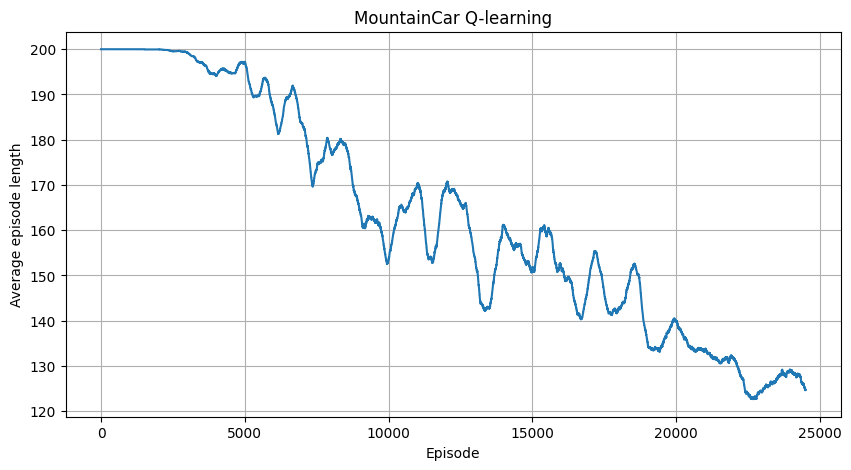

In [6]:
window = 500

moving_average = np.convolve(
    episode_lengths,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average episode length")
plt.title("MountainCar Q-learning")
plt.grid()

plt.show()

In [7]:
success = 0
for succ in successes:
    success += succ
    
success_rate = success / num_episodes

print(
    f"Successful episodes: "
    f"{int(success)} / {num_episodes}"
)

print(
    f"Success rate: "
    f"{100 * success_rate:.2f}%"
)

print(
    f"Average episode length: "
    f"{np.mean(episode_lengths):.2f} steps"
)

Successful episodes: 18312 / 25000
Success rate: 73.25%
Average episode length: 162.89 steps


In [15]:
import gymnasium as gym
import numpy as np
import time

# Create a separate environment for visualization
test_env = gym.make("MountainCar-v0", render_mode="human")

num_test_episodes = 5

test_successes = 0
test_episode_lengths = []

for episode in range(num_test_episodes):

    state, info = test_env.reset(seed=episode)
    state = discretize_state(state)

    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):

        # Pure exploitation with random tie-breaking
        max_actions = np.flatnonzero(
            Q[state] == np.max(Q[state])
        )
        action = rng.choice(max_actions)

        next_state_continuous, reward, terminated, truncated, info = \
            test_env.step(action)

        state = discretize_state(next_state_continuous)
        steps += 1

        # Slow it down a little so you can watch it
        time.sleep(0.02)

    test_successes += int(terminated)
    test_episode_lengths.append(steps)

    print(
        f"Test episode {episode+1}: "
        f"{'SUCCESS' if terminated else 'FAIL'} "
        f"in {steps} steps"
    )

test_env.close()

print("\nTest summary:")
print(f"Successful episodes: {test_successes} / {num_test_episodes}")
print(f"Average episode length: {np.mean(test_episode_lengths):.2f}")

Test episode 1: SUCCESS in 128 steps
Test episode 2: SUCCESS in 107 steps
Test episode 3: SUCCESS in 111 steps
Test episode 4: SUCCESS in 108 steps
Test episode 5: SUCCESS in 156 steps

Test summary:
Successful episodes: 5 / 5
Average episode length: 122.00


In [9]:
traj_env = gym.make("MountainCar-v0")

state_continuous, info = traj_env.reset(seed=102)
state = discretize_state(state_continuous)

terminated = False
truncated = False

trajectory = [state_continuous.copy()]

while not (terminated or truncated):

    max_actions = np.flatnonzero(
        Q[state] == np.max(Q[state])
    )
    action = rng.choice(max_actions)

    next_state_continuous, reward, terminated, truncated, info = \
        traj_env.step(action)

    trajectory.append(next_state_continuous.copy())

    state = discretize_state(next_state_continuous)

traj_env.close()

trajectory = np.array(trajectory)

print("Trajectory length:", len(trajectory))
print("Reached goal:", terminated)

Trajectory length: 112
Reached goal: True


In [10]:
policy = np.argmax(Q, axis=2)
print(policy.shape)

(40, 40)


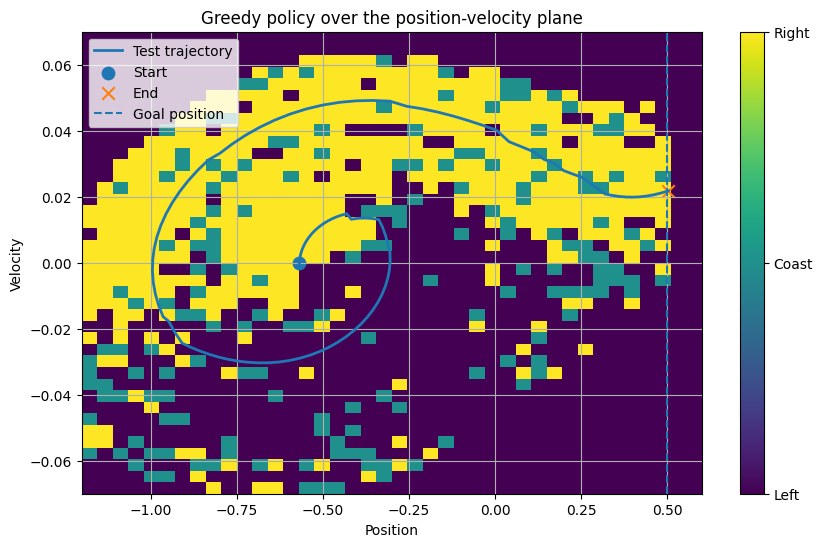

In [11]:
import matplotlib.pyplot as plt

action_labels = {
    0: "Left",
    1: "Coast",
    2: "Right"
}

plt.figure(figsize=(10, 6))

im = plt.imshow(
    policy.T,
    origin="lower",
    aspect="auto",
    extent=[
        env.observation_space.low[0],
        env.observation_space.high[0],
        env.observation_space.low[1],
        env.observation_space.high[1]
    ]
)

cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["Left", "Coast", "Right"])

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Greedy policy over the position-velocity plane")

# Overlay trajectory of one test episode
plt.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    linewidth=2,
    label="Test trajectory"
)

# Mark start and end
plt.scatter(
    trajectory[0, 0],
    trajectory[0, 1],
    marker="o",
    s=80,
    label="Start"
)

plt.scatter(
    trajectory[-1, 0],
    trajectory[-1, 1],
    marker="x",
    s=80,
    label="End"
)

# Goal position
plt.axvline(x=0.5, linestyle="--", label="Goal position")

plt.legend()
plt.grid()
plt.show()

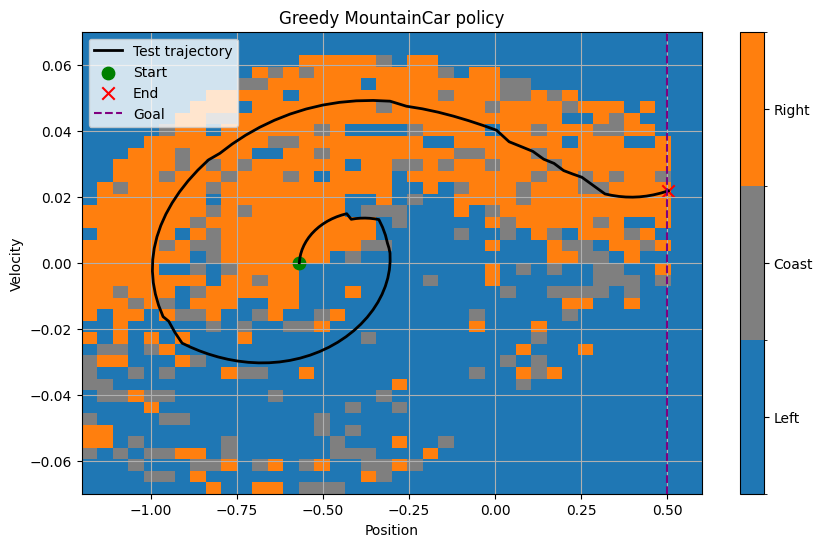

In [12]:
from matplotlib.colors import ListedColormap, BoundaryNorm

cmap = ListedColormap(["tab:blue", "tab:gray", "tab:orange"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

plt.figure(figsize=(10, 6))

im = plt.imshow(
    policy.T,
    origin="lower",
    aspect="auto",
    extent=[
        env.observation_space.low[0],
        env.observation_space.high[0],
        env.observation_space.low[1],
        env.observation_space.high[1]
    ],
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["Left", "Coast", "Right"])

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Greedy MountainCar policy")

plt.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    color="black",
    linewidth=2,
    label="Test trajectory"
)

plt.scatter(
    trajectory[0, 0],
    trajectory[0, 1],
    marker="o",
    s=80,
    color="green",
    label="Start"
)

plt.scatter(
    trajectory[-1, 0],
    trajectory[-1, 1],
    marker="x",
    s=80,
    color="red",
    label="End"
)

plt.axvline(x=0.5, linestyle="--", color="purple", label="Goal")

plt.legend()
plt.grid()
plt.show()

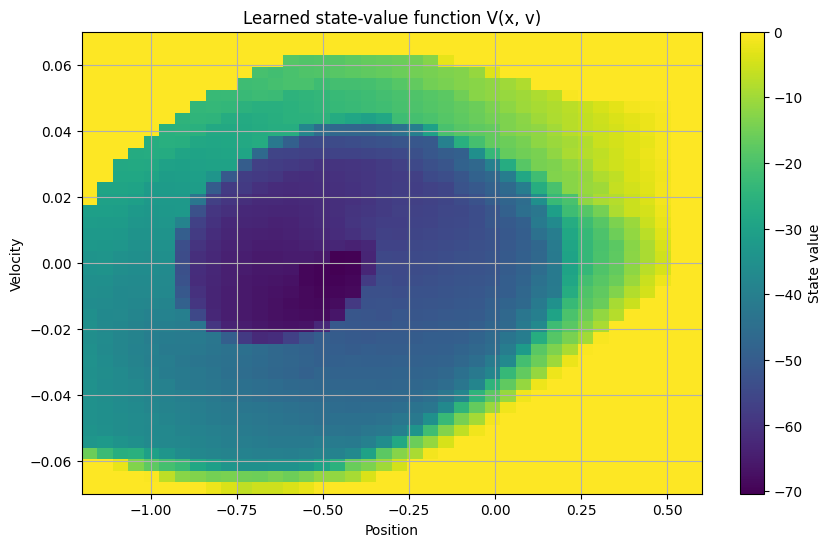

In [13]:
V = np.max(Q, axis=2)

plt.figure(figsize=(10, 6))

plt.imshow(
    V.T,
    origin="lower",
    aspect="auto",
    extent=[
        env.observation_space.low[0],
        env.observation_space.high[0],
        env.observation_space.low[1],
        env.observation_space.high[1]
    ]
)

plt.colorbar(label="State value")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Learned state-value function V(x, v)")
plt.grid()
plt.show()

In [14]:
print("Last 1000 success rate:",
      np.mean(successes[-1000:]))

print("Last 1000 average length:",
      np.mean(episode_lengths[-1000:]))

Last 1000 success rate: 1.0
Last 1000 average length: 126.774
